# Лабораторная работа: Метод главных компонент (PCA)

In [1]:
import math
from typing import List, Tuple, Optional

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

In [2]:
class Matrix:
    def __init__(self, data: List[List[float]]):
        if not data or not isinstance(data[0], (list, tuple)):
            raise ValueError("Matrix ожидает непустой список списков")
        self.data = [[float(x) for x in row] for row in data]
        self.rows = len(self.data)
        self.cols = len(self.data[0])
        for row in self.data:
            if len(row) != self.cols:
                raise ValueError("Все строки матрицы должны быть одной длины")

    def __getitem__(self, i):
        return self.data[i]

    @property
    def shape(self) -> Tuple[int, int]:
        return (self.rows, self.cols)

    def copy(self) -> "Matrix":
        return Matrix([row[:] for row in self.data])

    @staticmethod
    def zeros(rows: int, cols: int) -> "Matrix":
        return Matrix([[0.0] * cols for _ in range(rows)])

    @staticmethod
    def identity(n: int) -> "Matrix":
        return Matrix([[1.0 if i == j else 0.0 for j in range(n)] for i in range(n)])

    @staticmethod
    def from_column(vec: List[float]) -> "Matrix":
        return Matrix([[v] for v in vec])

    def transpose(self) -> "Matrix":
        return Matrix([[self.data[i][j] for i in range(self.rows)] for j in range(self.cols)])

    @property
    def T(self) -> "Matrix":
        return self.transpose()

    def __add__(self, other: "Matrix") -> "Matrix":
        self._check_same_shape(other)
        return Matrix([[self.data[i][j] + other.data[i][j]
                        for j in range(self.cols)] for i in range(self.rows)])

    def __sub__(self, other: "Matrix") -> "Matrix":
        self._check_same_shape(other)
        return Matrix([[self.data[i][j] - other.data[i][j]
                        for j in range(self.cols)] for i in range(self.rows)])

    def scale(self, alpha: float) -> "Matrix":
        return Matrix([[alpha * self.data[i][j]
                        for j in range(self.cols)] for i in range(self.rows)])

    def __mul__(self, alpha: float) -> "Matrix":
        return self.scale(alpha)
    __rmul__ = __mul__

    def matmul(self, other: "Matrix") -> "Matrix":
        if self.cols != other.rows:
            raise ValueError(f"Несовместимые размеры: {self.shape} и {other.shape}")
        result = [[0.0] * other.cols for _ in range(self.rows)]
        for i in range(self.rows):
            for j in range(other.cols):
                for k in range(self.cols):
                    result[i][j] += self.data[i][k] * other.data[k][j]
        return Matrix(result)

    def __matmul__(self, other: "Matrix") -> "Matrix":
        return self.matmul(other)

    def _check_same_shape(self, other: "Matrix"):
        if self.shape != other.shape:
            raise ValueError(f"Размеры не совпадают: {self.shape} и {other.shape}")

    def column_means(self) -> List[float]:
        return [sum(self.data[i][j] for i in range(self.rows)) / self.rows
                for j in range(self.cols)]

    def determinant(self) -> float:
        """Определитель методом Гаусса с частичным выбором ведущего элемента."""
        if self.rows != self.cols:
            raise ValueError("Определитель определён только для квадратной матрицы")
        n = self.rows
        a = [row[:] for row in self.data]
        det = 1.0
        for col in range(n):
            pivot_row = max(range(col, n), key=lambda r: abs(a[r][col]))
            if abs(a[pivot_row][col]) < 1e-15:
                return 0.0
            if pivot_row != col:
                a[col], a[pivot_row] = a[pivot_row], a[col]
                det = -det
            det *= a[col][col]
            for r in range(col + 1, n):
                factor = a[r][col] / a[col][col]
                for c in range(col, n):
                    a[r][c] -= factor * a[col][c]
        return det

    def __repr__(self) -> str:
        rows = [" [" + ", ".join(f"{x:8.4f}" for x in row) + "]" for row in self.data]
        return "Matrix([\n" + "\n".join(rows) + "\n])"

## EASY LEVEL

### Задание (Easy): Реализовать метод Гаусса для решения СЛАУ

$$ A x = b. $$

In [3]:
def gauss_solver(A: "Matrix", b: "Matrix", tol: float = 1e-9) -> List["Matrix"]:
    """
    Вход:
        A: матрица коэффициентов (n × n). Используется класс Matrix из предыдущей лабораторной работы
        b: вектор правых частей (n × 1)
    Выход:
        list[Matrix]: список базисных векторов решения системы
    Raises:
        ValueError: если система несовместна
    """
    n = A.rows
    m = A.cols
    aug = [A.data[i][:] + [b.data[i][0]] for i in range(n)]
    pivot_tol = tol

    pivot_cols: List[int] = []
    row = 0
    for col in range(m):
        pr = max(range(row, n), key=lambda r: abs(aug[r][col])) if row < n else row
        if row >= n or abs(aug[pr][col]) < pivot_tol:
            continue
        aug[row], aug[pr] = aug[pr], aug[row]
        pv = aug[row][col]
        aug[row] = [x / pv for x in aug[row]]
        for r in range(n):
            if r != row and abs(aug[r][col]) > 0.0:
                f = aug[r][col]
                aug[r] = [aug[r][c] - f * aug[row][c] for c in range(m + 1)]
        pivot_cols.append(col)
        row += 1
        if row == n:
            break

    # проверка совместности
    for r in range(n):
        if all(abs(aug[r][c]) < pivot_tol for c in range(m)) and abs(aug[r][m]) > pivot_tol:
            raise ValueError("Система несовместна")

    free_cols = [c for c in range(m) if c not in pivot_cols]
    is_homogeneous = all(abs(b.data[i][0]) < pivot_tol for i in range(n))

    null_basis: List["Matrix"] = []
    for fc in free_cols:
        x = [0.0] * m
        x[fc] = 1.0
        for r, pc in enumerate(pivot_cols):
            x[pc] = -aug[r][fc]
        null_basis.append(Matrix.from_column(x))

    if is_homogeneous:
        return null_basis

    xp = [0.0] * m
    for r, pc in enumerate(pivot_cols):
        xp[pc] = aug[r][m]
    return [Matrix.from_column(xp)] + null_basis

In [4]:
# единственное решение (ожидаем x=2, y=3, z=-1)
A = Matrix([[2, 1, -1], [-3, -1, 2], [-2, 1, 2]])
b = Matrix.from_column([8, -11, -3])
sol = gauss_solver(A, b)
print("Решение:", [round(sol[0].data[i][0], 6) for i in range(3)])

# недоопределённая система
A2 = Matrix([[1, 1, 1], [0, 1, -1]])
b2 = Matrix.from_column([6, 1])
sol2 = gauss_solver(A2, b2)
print("Частное решение:", [round(sol2[0].data[i][0], 4) for i in range(3)])
print("Базис нуль-пространства:", [round(sol2[1].data[i][0], 4) for i in range(3)])

Решение: [2.0, 3.0, -1.0]
Частное решение: [5.0, 1.0, 0.0]
Базис нуль-пространства: [-2.0, 1.0, 1.0]


### Задание (Easy): Реализовать функцию центрирования данных

$$ X_{\text{centered}} = X - \operatorname{mean}(X). $$

In [5]:
def center_data(X: "Matrix") -> "Matrix":
    """
    Вход: матрица данных X (n × m)
    Выход: центрированная матрица X_centered (n × m)
    """
    means = X.column_means()
    return Matrix([[X.data[i][j] - means[j] for j in range(X.cols)]
                   for i in range(X.rows)])

### Задание (Easy): Вычислить матрицу ковариаций

$$ C = \frac{1}{n-1}\, X_c^{\mathsf T} X_c. $$

In [6]:
def covariance_matrix(X_centered: "Matrix") -> "Matrix":
    """
    Вход: центрированная матрица X_centered (n × m)
    Выход: матрица ковариаций C (m × m)
    """
    n = X_centered.rows
    if n < 2:
        raise ValueError("Для оценки ковариации нужно как минимум 2 объекта")
    C = X_centered.T @ X_centered
    return C.scale(1.0 / (n - 1))

In [7]:
# Демонстрация центрирования и ковариации на маленьком наборе
X_demo = Matrix([[1.0, 2.0], [3.0, 6.0], [5.0, 4.0]])
Xc_demo = center_data(X_demo)
print("Средние по столбцам исходных данных:", [round(v, 4) for v in X_demo.column_means()])
print("Средние после центрирования:", [round(v, 12) for v in Xc_demo.column_means()])
print("Матрица ковариаций:")
print(covariance_matrix(Xc_demo))

Средние по столбцам исходных данных: [3.0, 4.0]
Средние после центрирования: [0.0, 0.0]
Матрица ковариаций:
Matrix([
 [  4.0000,   2.0000]
 [  2.0000,   4.0000]
])


## NORMAL LEVEL

### Задание (Normal): Найти собственные значения матрицы $C$ методом бисекции

$$ \det(C - \lambda I) = 0. $$

In [8]:
def _char_poly(C: "Matrix", lam: float) -> float:
    """Значение характеристического многочлена det(C - lam*I)."""
    n = C.rows
    M = Matrix([[C.data[i][j] - (lam if i == j else 0.0)
                 for j in range(n)] for i in range(n)])
    return M.determinant()


def _bisection_root(f, a: float, b: float, tol: float) -> float:
    """Корень f на [a, b] методом бисекции (предполагается f(a)*f(b) <= 0)."""
    fa, fb = f(a), f(b)
    if fa == 0.0:
        return a
    if fb == 0.0:
        return b
    for _ in range(200):
        if b - a <= tol:
            break
        mid = 0.5 * (a + b)
        fm = f(mid)
        if fm == 0.0:
            return mid
        if fa * fm < 0.0:
            b, fb = mid, fm
        else:
            a, fa = mid, fm
    return 0.5 * (a + b)


def find_eigenvalues(C: "Matrix", tol: float = 1e-6) -> List[float]:
    """
    Вход:
        C: матрица ковариаций (m × m)
        tol: допустимая погрешность
    Выход: список вещественных собственных значений
    """
    n = C.rows
    # все собственные значения по модулю не больше наибольшей суммы модулей в строке
    # из C*v = lam*v |lam| <= sum_j |c_ij|
    R = max(sum(abs(C.data[i][j]) for j in range(n)) for i in range(n))
    pad = max(1e-3, 0.05 * R)
    lo, hi = -R - pad, R + pad

    f = lambda l: _char_poly(C, l)
    N = max(5000, 1000 * n)
    step = (hi - lo) / N

    roots: List[float] = []
    x_prev, v_prev = lo, f(lo)
    for i in range(1, N + 1):
        x = lo + i * step
        v = f(x)
        if v_prev == 0.0:
            roots.append(x_prev)
        elif v_prev * v < 0.0:
            roots.append(_bisection_root(f, x_prev, x, tol))
        x_prev, v_prev = x, v

    roots.sort()
    merged: List[float] = []
    for r in roots:
        if merged and abs(r - merged[-1]) <= max(10 * tol, 1e-9):
            continue
        merged.append(r)
    merged.sort(reverse=True)
    return [0.0 if abs(r) < 1e-6 else r for r in merged]

In [9]:
# Проверка на матрицах с известным спектром
C_known = Matrix([[2, 1], [1, 2]])         # собственные значения: 3 и 1
print("[[2,1],[1,2]] ->", [round(x, 6) for x in find_eigenvalues(C_known)])

C_diag = Matrix([[2, 0, 0], [0, 5, 0], [0, 0, 3]])   # 5, 3, 2
print("diag(2,5,3) ->", [round(x, 6) for x in find_eigenvalues(C_diag)])

[[2,1],[1,2]] -> [3.0, 1.0]
diag(2,5,3) -> [5.0, 3.0, 2.0]


### Задание (Normal): Найти собственные векторы матрицы $C$

$$ (C - \lambda I)\, v = 0. $$

In [10]:
def find_eigenvectors(C: "Matrix", eigenvalues: List[float]) -> List["Matrix"]:
    """
    Вход:
        C: матрица ковариаций (m × m)
        eigenvalues: список собственных значений
    Выход: список собственных векторов (каждый вектор - объект Matrix)
    """
    n = C.rows
    zero = Matrix.zeros(n, 1)
    eigenvectors: List["Matrix"] = []
    for lam in eigenvalues:
        M = Matrix([[C.data[i][j] - (lam if i == j else 0.0)
                     for j in range(n)] for i in range(n)])
        basis = gauss_solver(M, zero, tol=1e-4)
        v = basis[0]
        norm = math.sqrt(sum(v.data[i][0] ** 2 for i in range(n)))
        if norm > 0:
            v = v.scale(1.0 / norm)
        eigenvectors.append(v)
    return eigenvectors

In [11]:
# Проверка: C v должно равняться lambda v
C_known = Matrix([[2, 1], [1, 2]])
eigvals = find_eigenvalues(C_known)
eigvecs = find_eigenvectors(C_known, eigvals)
for lam, v in zip(eigvals, eigvecs):
    Cv = C_known @ v
    resid = max(abs(Cv.data[i][0] - lam * v.data[i][0]) for i in range(2))
    print(f"lambda={lam:.4f}  v={[round(v.data[i][0], 4) for i in range(2)]}  "
          f"||Cv - lambda*v|| = {resid:.2e}")

lambda=3.0000  v=[0.7071, 0.7071]  ||Cv - lambda*v|| = 2.07e-08
lambda=1.0000  v=[-0.7071, 0.7071]  ||Cv - lambda*v|| = 2.83e-07


### Задание (Normal): Вычислить долю объяснённой дисперсии

$$ \gamma = \frac{\sum_{i=1}^{k}\lambda_i}{\sum_{i=1}^{m}\lambda_i}. $$

In [12]:
def explained_variance_ratio(eigenvalues: List[float], k: int) -> float:
    """
    Вход:
        eigenvalues: список собственных значений
        k: число компонент
    Выход: доля объяснённой дисперсии
    """
    total = sum(eigenvalues)
    if total == 0:
        return 0.0
    k = max(0, min(k, len(eigenvalues)))
    return sum(eigenvalues[:k]) / total

## HARD LEVEL

### Задание (Hard): Реализовать полный алгоритм PCA

1. Центрирование данных.
2. Вычисление матрицы выборочных ковариаций.
3. Нахождение собственных значений и векторов.
4. Проекция данных на главные компоненты.

In [13]:
def _sorted_eigsystem(C: "Matrix", tol: float = 1e-9):
    """Собственные значения и векторы, отсортированные по убыванию значений."""
    eigvals = find_eigenvalues(C, tol=max(tol, 1e-9))
    eigvecs = find_eigenvectors(C, eigvals)
    pairs = sorted(zip(eigvals, eigvecs), key=lambda p: p[0], reverse=True)
    return [p[0] for p in pairs], [p[1] for p in pairs]


def _stack_columns(vectors: List["Matrix"]) -> "Matrix":
    m, k = vectors[0].rows, len(vectors)
    return Matrix([[vectors[j].data[i][0] for j in range(k)] for i in range(m)])


def pca(X: "Matrix", k: int) -> Tuple["Matrix", float]:
    """
    Вход:
        X: матрица данных (n × m)
        k: число главных компонент
    Выход:
        X_proj: проекция данных (n × k)
        gamma: доля объяснённой дисперсии
    """
    Xc = center_data(X)
    C = covariance_matrix(Xc)
    eigvals, eigvecs = _sorted_eigsystem(C)
    k = max(1, min(k, len(eigvecs)))
    Vk = _stack_columns(eigvecs[:k])
    X_proj = Xc @ Vk
    return X_proj, explained_variance_ratio(eigvals, k)

### Применение к датасету Iris

In [14]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = Matrix(iris.data.tolist())
y_iris = iris.target.tolist()

Xc = center_data(X_iris)
C = covariance_matrix(Xc)
eigvals, eigvecs = _sorted_eigsystem(C)

print("Собственные значения C:", [round(v, 5) for v in eigvals])
print(f"trace(C) = {sum(C.data[i][i] for i in range(C.rows)):.5f}  "
      f"(= сумма собственных значений = {sum(eigvals):.5f})")
print()
for k in range(1, 5):
    print(f"  k={k}: объяснённая дисперсия = {explained_variance_ratio(eigvals, k):.4f}")

X_proj, gamma = pca(X_iris, 2)
print(f"\nПроекция на 2 компоненты: размер {X_proj.shape}, "
      f"сохранено {gamma*100:.2f}% дисперсии.")

Собственные значения C: [4.22824, 0.24267, 0.07821, 0.02384]
trace(C) = 4.57296  (= сумма собственных значений = 4.57296)

  k=1: объяснённая дисперсия = 0.9246
  k=2: объяснённая дисперсия = 0.9777
  k=3: объяснённая дисперсия = 0.9948
  k=4: объяснённая дисперсия = 1.0000

Проекция на 2 компоненты: размер (150, 2), сохранено 97.77% дисперсии.


### Собственные значения и кумулятивная доля дисперсии

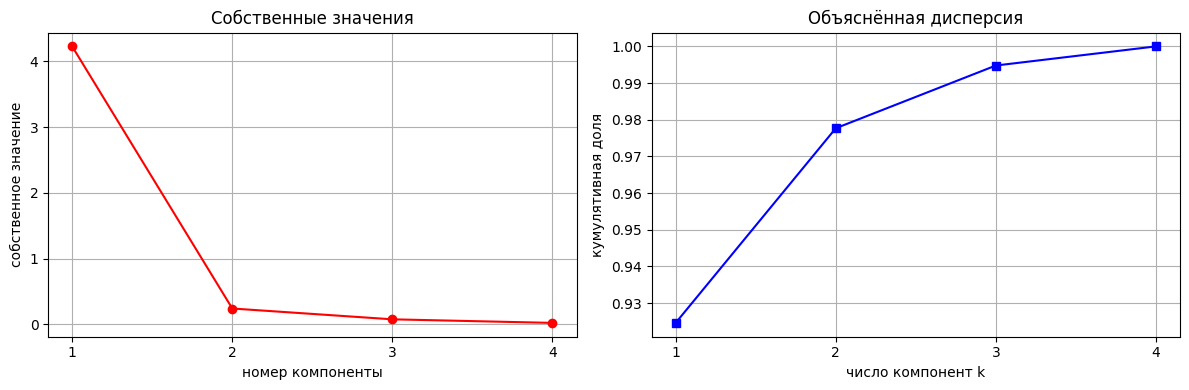

In [15]:
ks = list(range(1, len(eigvals) + 1))
cum = [explained_variance_ratio(eigvals, k) for k in ks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ks, eigvals, "o-", color="red")
ax1.set_xlabel("номер компоненты"); ax1.set_ylabel("собственное значение")
ax1.set_title("Собственные значения"); ax1.set_xticks(ks)
ax2.plot(ks, cum, "s-", color="blue")
ax2.set_xlabel("число компонент k"); ax2.set_ylabel("кумулятивная доля")
ax2.set_title("Объяснённая дисперсия"); ax2.set_xticks(ks)
fig.tight_layout()
plt.show()

### Задание (Hard): Визуализировать проекцию данных на первые две главные компоненты

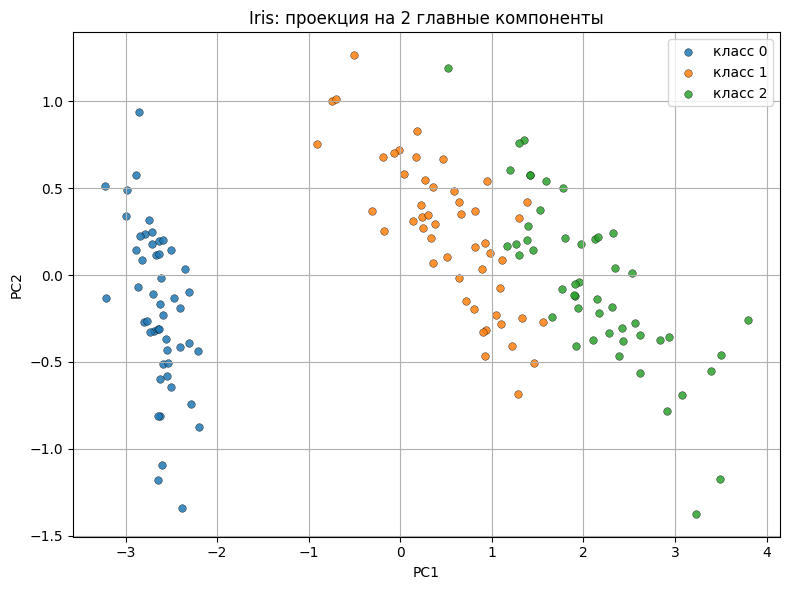

In [16]:
def plot_pca_projection(X_proj: "Matrix", labels: Optional[List] = None,
                        title: str = "Проекция на первые две главные компоненты"):
    """
    Вход: проекция данных X_proj (n × 2)
    Выход: объект Figure из Matplotlib
    """
    if X_proj.cols < 2:
        raise ValueError("Для визуализации нужно как минимум 2 компоненты")
    xs = [X_proj.data[i][0] for i in range(X_proj.rows)]
    ys = [X_proj.data[i][1] for i in range(X_proj.rows)]
    fig, ax = plt.subplots(figsize=(8, 6))
    if labels is None:
        ax.scatter(xs, ys, s=30, alpha=0.8, edgecolor="k", linewidth=0.3)
    else:
        cmap = plt.get_cmap("tab10")
        for idx, lab in enumerate(sorted(set(labels))):
            lx = [xs[i] for i in range(len(xs)) if labels[i] == lab]
            ly = [ys[i] for i in range(len(ys)) if labels[i] == lab]
            ax.scatter(lx, ly, s=30, alpha=0.85, color=cmap(idx % 10),
                       edgecolor="k", linewidth=0.3, label=f"класс {lab}")
        ax.legend()
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(title)
    fig.tight_layout()
    return fig


fig = plot_pca_projection(X_proj, labels=y_iris,
                          title="Iris: проекция на 2 главные компоненты")
plt.show()

### Задание (Hard): Вычислить среднеквадратическую ошибку восстановления данных

$$ \mathrm{MSE} = \frac{1}{n\,m}\sum_{i,j}\bigl(X_{\text{orig}} - X_{\text{recon}}\bigr)^2. $$

In [17]:
def reconstruction_error(X_orig: "Matrix", X_recon: "Matrix") -> float:
    """
    Вход:
        X_orig: исходные данные (n × m)
        X_recon: восстановленные данные (n × m)
    Выход: среднеквадратическая ошибка MSE
    """
    n, m = X_orig.shape
    total = sum((X_orig.data[i][j] - X_recon.data[i][j]) ** 2
                for i in range(n) for j in range(m))
    return total / (n * m)


def reconstruct(X: "Matrix", k: int) -> "Matrix":
    """Восстановление данных из k главных компонент."""
    means = X.column_means()
    Xc = center_data(X)
    _, eigvecs = _sorted_eigsystem(covariance_matrix(Xc))
    Vk = _stack_columns(eigvecs[:k])
    X_rec_c = (Xc @ Vk) @ Vk.T
    return Matrix([[X_rec_c.data[i][j] + means[j] for j in range(X.cols)]
                   for i in range(X.rows)])

In [18]:
for k in range(1, 5):
    mse = reconstruction_error(X_iris, reconstruct(X_iris, k))
    print(f"k={k}: MSE = {mse:.6e}")

k=1: MSE = 8.560431e-02
k=2: MSE = 2.534107e-02
k=3: MSE = 5.919048e-03
k=4: MSE = 8.828433e-20


## Тестирование

In [19]:
import unittest

class TestPCA(unittest.TestCase):
    def setUp(self):
        self.C = Matrix([[2.0, 1.0], [1.0, 2.0]])     # спектр: 3, 1

    def test_gauss_unique(self):
        A = Matrix([[2, 1, -1], [-3, -1, 2], [-2, 1, 2]])
        b = Matrix.from_column([8, -11, -3])
        x = gauss_solver(A, b)[0]
        for got, exp in zip([x.data[i][0] for i in range(3)], [2, 3, -1]):
            self.assertAlmostEqual(got, exp, places=6)

    def test_gauss_inconsistent(self):
        with self.assertRaises(ValueError):
            gauss_solver(Matrix([[1, 1], [1, 1]]), Matrix.from_column([1, 2]))

    def test_eigenvalues(self):
        ev = find_eigenvalues(self.C)
        self.assertEqual(len(ev), 2)
        self.assertAlmostEqual(ev[0], 3.0, places=5)
        self.assertAlmostEqual(ev[1], 1.0, places=5)

    def test_trace_equals_sum(self):
        C = covariance_matrix(center_data(Matrix(load_iris().data.tolist())))
        ev = find_eigenvalues(C)
        self.assertAlmostEqual(sum(ev), sum(C.data[i][i] for i in range(C.rows)), places=4)

    def test_eigenvector_identity(self):
        ev = find_eigenvalues(self.C)
        for lam, v in zip(ev, find_eigenvectors(self.C, ev)):
            Cv = self.C @ v
            for i in range(2):
                self.assertAlmostEqual(Cv.data[i][0], lam * v.data[i][0], places=5)

    def test_orthonormal_basis(self):
        C = covariance_matrix(center_data(Matrix(load_iris().data.tolist())))
        _, vecs = _sorted_eigsystem(C)
        V = _stack_columns(vecs)
        G = V.T @ V
        for i in range(V.cols):
            for j in range(V.cols):
                self.assertAlmostEqual(G.data[i][j], 1.0 if i == j else 0.0, places=6)

    def test_full_reconstruction(self):
        X = Matrix(load_iris().data.tolist())
        self.assertLess(reconstruction_error(X, reconstruct(X, 4)), 1e-12)

    def test_explained_variance_monotonic(self):
        ev = find_eigenvalues(covariance_matrix(center_data(Matrix(load_iris().data.tolist()))))
        self.assertAlmostEqual(explained_variance_ratio(ev, 4), 1.0, places=6)
        self.assertLessEqual(explained_variance_ratio(ev, 1), explained_variance_ratio(ev, 2))


_ = unittest.main(argv=["", "-v"], verbosity=2, exit=False)

test_eigenvalues (__main__.TestPCA) ... ok
test_eigenvector_identity (__main__.TestPCA) ... ok
test_explained_variance_monotonic (__main__.TestPCA) ... ok
test_full_reconstruction (__main__.TestPCA) ... ok
test_gauss_inconsistent (__main__.TestPCA) ... ok
test_gauss_unique (__main__.TestPCA) ... ok
test_orthonormal_basis (__main__.TestPCA) ... ok
test_trace_equals_sum (__main__.TestPCA) ... ok

----------------------------------------------------------------------
Ran 8 tests in 0.355s

OK
